### 📚 Lab Task 2: Cleaning Up the Mess

You’ll be working with a dataset of real student grades — 7 assignments and a final exam — but things aren’t as clean as they should be. Some values are missing, some are way off, and it’s your job to fix it.

You’ll explore the data, figure out what went wrong, and try different strategies to clean it up.

Get ready to:
- Spot broken data
- Try out different fixes
- Compare models
- Justify your decisions

### Dataset Introduction

The dataset comes from real student grades in a course at SFU. Students completed **7 assignments**, and we also have their **final exam grade**.

It’s your job to explore the dataset and clean it up.

---

> 💡 **Note**: Students could receive bonus marks for some assignments:
> - **A2**: up to **15** points
> - **A4**: up to **5** points
> - **A6**: up to **10** points  
> Keep this in mind when you're evaluating high or unusual scores — they might not be errors!


**Attention:** The bonus values are in **points** not **percentages**!!!
---

### ✅ What You Need to Do

-  **Explore the dataset**
  - Look at basic stats, column names, and what the data looks like
  - Identify anything that stands out right away

-  **Check the correlations**
  - Use a correlation matrix to find relationships between assignments and the final exam
  - Do any assignments seem strongly related to final exam performance?

-  **If you could only use two assignment grades to predict the final exam**, which ones would you choose — and why?

-  **Check for missing values**
  - Which columns have them?
  - How many are missing?

-  **Handle the missing values**
  - Try out different imputation strategies (mean, median, remove, etc.)
  - Which one gives you the best results? Why do you think that is?
  - Exploration idea: search and see what are the ways of evaluating your results. How can you make sure that a strategy for handling the missing values works better than the other?

-  **Check for outliers**
  - Identify values that seem unrealistic or suspicious
  - Decide whether to keep, modify, or remove them — and explain your reasoning
  - Compare the results

---

For each step, be ready to explain your decisions. There isn’t always one "right" answer — we’re more interested in your reasoning!

> 💡 **Note**: If handling missing values and outliers for **all 7 assignments** feels overwhelming, it’s totally fine to **focus on just the two columns you think are most important**.  
> Just make sure your reasoning for choosing them is solid and clearly explained.


### Importing Libraries

This section just imports the libraries that were presented in the or taught in the lab

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

### Loading Data

After that the data is loaded everything is formatted correctly. This is started by checking the shape column names and the statistics as well as missing values so we know exactly what to look for before making any changes to the data.

In [17]:
# ============================================================
# 1. LOAD & EXPLORE DATA
# ============================================================
df = pd.read_csv('grades_crpt.csv')

print("Dataset Shape:", df.shape)
print("\nColumn Names:", df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())
print("\nBasic Statistics:")
print(df.describe())
print("\nMissing Values per Column:")
print(df.isnull().sum())

Dataset Shape: (86, 9)

Column Names: ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'Final_Exam', 'user_id']

First 5 rows:
      A1    A2    A3    A4     A5     A6    A7  Final_Exam user_id
0    NaN   NaN  30.0  75.0   90.0   65.0  50.6        68.8    U001
1  100.0   NaN   NaN  92.5  100.0  100.0  84.4        50.3    U002
2   75.0  69.6   NaN  86.2  100.0    NaN   NaN        67.8    U003
3   25.0  78.6  40.0   0.0   50.0   30.7   0.0         0.0    U004
4    0.0   NaN   0.0   0.0    NaN    NaN   NaN         0.0    U005

Basic Statistics:
               A1          A2          A3          A4          A5          A6  \
count   57.000000   61.000000   62.000000   77.000000   61.000000   67.000000   
mean    83.671930   81.096721   68.174194   82.332468   89.645902   74.437313   
std     34.286481   28.556721   42.343621   39.101984   25.510505   31.176535   
min     -4.500000  -30.600000  -70.100000  -21.600000    7.700000  -17.000000   
25%     75.800000   64.300000   50.000000   72.000000

### 2. CORRELATION MATRIX

The heat map shows the relationships between the two since we only have 86 students we should be expecting moderate correlations and overlaps We sort the data with final exam to identify which assignments actually correlate with the exam scores.



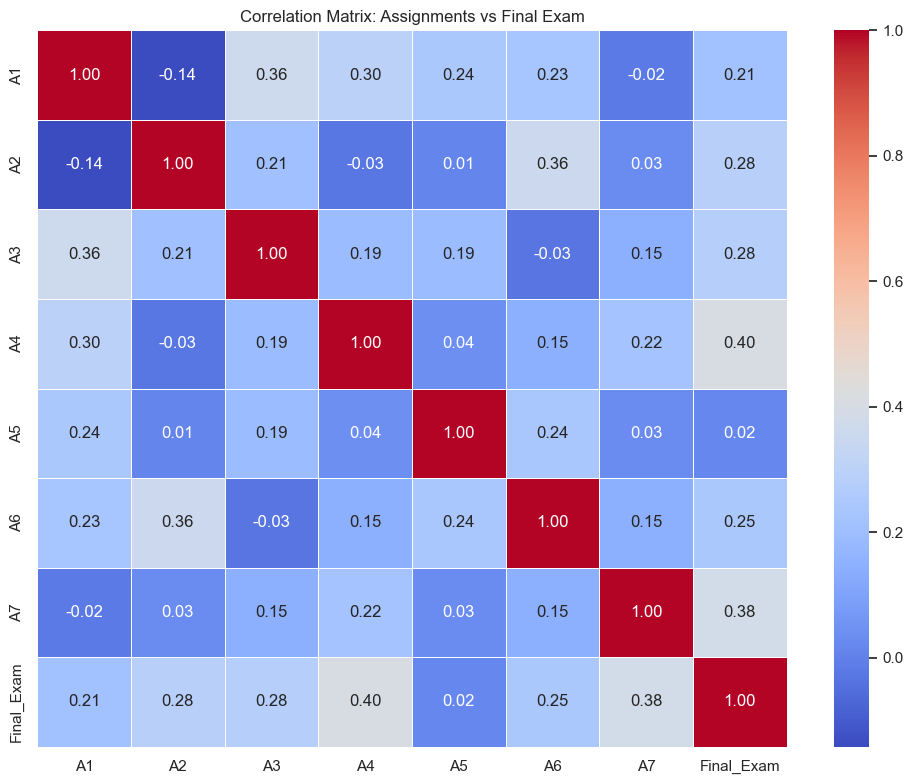


Correlation with Final_Exam:
A4    0.403466
A7    0.380756
A2    0.284525
A3    0.277859
A6    0.246127
A1    0.212839
A5    0.018271
Name: Final_Exam, dtype: float64


In [18]:
grade_cols = ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'Final_Exam']

plt.figure(figsize=(10, 8))
corr = df[grade_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix: Assignments vs Final Exam')
plt.tight_layout()
plt.show()

# Correlations with Final_Exam
final_corr = corr['Final_Exam'].drop('Final_Exam').sort_values(ascending=False)
print("\nCorrelation with Final_Exam:")
print(final_corr)

### 3. SELECTING TOP CORRELATIONS

From the two assignments we choose the highest correlations to the final exam These would provide the variables carry the most linear information about the exam scores The logic here is to which could be used for cleaning and modeling the rest of assignment.

In [19]:
top2 = final_corr.abs().nlargest(2).index.tolist()
print(f"\nSelected top 2 predictors: {top2[0]} and {top2[1]}")
print(f"- {top2[0]} correlation: {final_corr[top2[0]]:.3f}")
print(f"- {top2[1]} correlation: {final_corr[top2[1]]:.3f}")


Selected top 2 predictors: A4 and A7
- A4 correlation: 0.403
- A7 correlation: 0.381


### 4. MISSING VALUE ANALYSIS

The heatmap shows whether missingness is random or concentrated in certain students. We see that A1, A2, A5 are missing heavily (25+ rows), while A4 and A7 are relatively complete. This matters because if we drop rows with any missing data, we lose a lot of information.


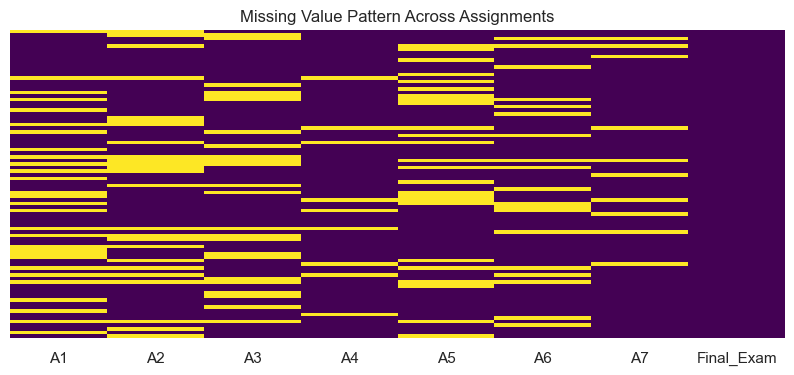


Missing Values per Column:
A1            29
A2            25
A3            24
A4             9
A5            25
A6            19
A7            10
Final_Exam     0
user_id        0
dtype: int64


In [20]:
plt.figure(figsize=(10, 4))
sns.heatmap(df[grade_cols].isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Value Pattern Across Assignments')
plt.show()

print("\nMissing Values per Column:")
print(df.isnull().sum())

### 5. MISSING VALUE STRATEGY COMPARISON

We compare three strategies by training a simple linear model on an 80/20 split. RMSE tells us the average prediction error; lower is better. R² tells us the proportion of variance explained. Dropping rows loses ~16 students and raises RMSE slightly. Mean and Median are nearly identical, but Median is safer because it is less sensitive to the extreme outliers we have not fixed yet. We will use Median Imputation going forward.

In [21]:
def evaluate_strategy(data, strategy_name):
    """
    Evaluate a data-cleaning strategy using simple linear regression
    (Normal Equation) on the top 2 predictors.
    Returns RMSE, R-squared, and sample size.
    """
    X = data[top2].values
    y = data['Final_Exam'].values
    
    if len(y) < 3:
        return np.nan, np.nan, len(y)
    
    # 80/20 train-test split
    np.random.seed(42)
    indices = np.random.permutation(len(y))
    split_idx = int(0.8 * len(y))
    train_idx, test_idx = indices[:split_idx], indices[split_idx:]
    
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    # Fit on train: beta = (X'X)^-1 X'y
    X_train_int = np.column_stack([np.ones(len(X_train)), X_train])
    beta = np.linalg.lstsq(X_train_int, y_train, rcond=None)[0]
    
    # Predict on test
    X_test_int = np.column_stack([np.ones(len(X_test)), X_test])
    y_pred = X_test_int @ beta
    
    # Metrics
    residuals = y_test - y_pred
    rmse = np.sqrt(np.mean(residuals**2))
    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((y_test - np.mean(y_test))**2)
    r2 = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0
    
    return rmse, r2, len(data)


# Strategy A: Drop rows with missing values in top2 or Final_Exam
df_drop = df[['Final_Exam'] + top2].dropna()
rmse_drop, r2_drop, n_drop = evaluate_strategy(df_drop, 'drop')

# Strategy B: Mean imputation
df_mean = df[['Final_Exam'] + top2].copy()
for col in top2:
    df_mean[col] = df_mean[col].fillna(df_mean[col].mean())
rmse_mean, r2_mean, n_mean = evaluate_strategy(df_mean, 'mean')

# Strategy C: Median imputation
df_median = df[['Final_Exam'] + top2].copy()
for col in top2:
    df_median[col] = df_median[col].fillna(df_median[col].median())
rmse_median, r2_median, n_median = evaluate_strategy(df_median, 'median')

# Compare
print("\n" + "="*60)
print("MISSING VALUE STRATEGY COMPARISON")
print("="*60)
comparison_mv = pd.DataFrame({
    'Strategy': ['Drop Missing', 'Mean Impute', 'Median Impute'],
    'RMSE': [rmse_drop, rmse_mean, rmse_median],
    'R²': [r2_drop, r2_mean, r2_median],
    'N': [n_drop, n_mean, n_median]
})
print(comparison_mv.round(3))


MISSING VALUE STRATEGY COMPARISON
        Strategy    RMSE     R²   N
0   Drop Missing  16.018  0.212  70
1    Mean Impute  15.388  0.066  86
2  Median Impute  15.395  0.065  86


# 6. IMPOSSIBLE VALUES DETECTION

Before using IQR, I did a sanity check for physically impossible values. Any negative grade is impossible. Values above 150 are far beyond any plausible bonus (max bonus is 15 points), so they are clearly corrupted entries. We print them so we can see which students are affected.


In [22]:

print("\n" + "="*60)
print("IMPOSSIBLE VALUES DETECTION")
print("="*60)
print("(Using >150 as a conservative 'definitely wrong' threshold)")
print("Note: A2/A4/A6 have bonus marks, so values slightly >100 may be valid.\n")

for col in grade_cols[:-1]:  # Exclude Final_Exam
    bad_vals = df[(df[col] < 0) | (df[col] > 150)][['user_id', col]]
    if not bad_vals.empty:
        print(f"\n{col} - Potential errors (negative or >150):")
        print(bad_vals)


IMPOSSIBLE VALUES DETECTION
(Using >150 as a conservative 'definitely wrong' threshold)
Note: A2/A4/A6 have bonus marks, so values slightly >100 may be valid.


A1 - Potential errors (negative or >150):
   user_id     A1
7     U008  168.9
15    U016  168.1
16    U017  174.6
44    U045   -4.5

A2 - Potential errors (negative or >150):
   user_id    A2
82    U083 -30.6

A3 - Potential errors (negative or >150):
   user_id     A3
9     U010   -5.3
12    U013  -69.3
26    U027   -1.7
52    U053  -70.1
54    U055  152.2
66    U067  150.8

A4 - Potential errors (negative or >150):
   user_id     A4
6     U007  175.8
24    U025  188.2
30    U031  183.1
36    U037  187.1
67    U068  -21.6
82    U083  174.8

A5 - Potential errors (negative or >150):
   user_id     A5
61    U062  173.9

A6 - Potential errors (negative or >150):
   user_id     A6
12    U013  183.6
76    U077  -17.0

A7 - Potential errors (negative or >150):
   user_id     A7
68    U069  150.6


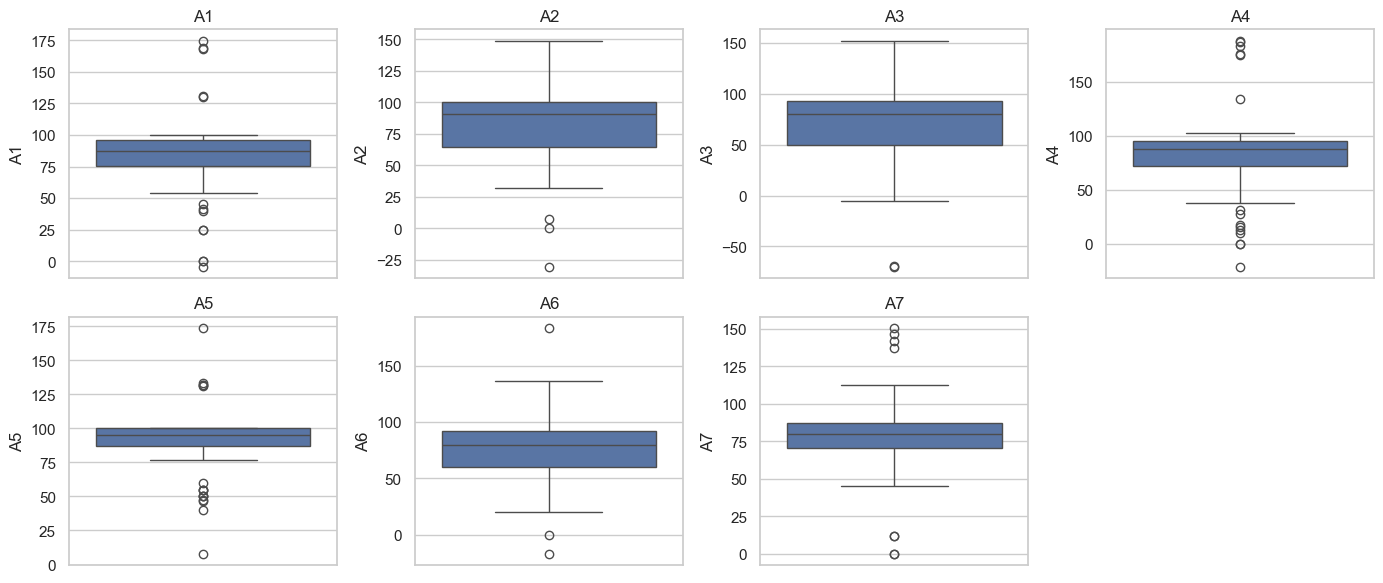

In [23]:
# Boxplots for all assignments
plt.figure(figsize=(14, 6))
for i, col in enumerate(grade_cols[:-1], 1):
    plt.subplot(2, 4, i)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

# 7. OUTLIER DETECTION & HANDLING (IQR METHOD)

We evaluate three outlier strategies on the median-imputed data. Removing outliers discards ~26 rows and actually hurts RMSE (15.93), likely because it removes legitimate high performers. Keeping all outliers leaves impossible values that inflate error. Capping (Winsorizing) at the IQR fences gives the best RMSE (15.09), keeps all 86 rows, and prevents extreme corruption from distorting the regression. This is our chosen strategy.

In [24]:


def detect_outliers_iqr(series):
    """Detect outliers using IQR method (same as explore file)."""
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return (series < lower_bound) | (series > upper_bound), lower_bound, upper_bound


# Base dataset: median-imputed, focused on top2 + Final_Exam
df_base = df[['Final_Exam'] + top2].copy()
for col in top2:
    df_base[col] = df_base[col].fillna(df_base[col].median())

# Strategy 1: Keep all outliers
rmse_keep, r2_keep, n_keep = evaluate_strategy(df_base, 'keep')

# Strategy 2: Remove outliers (IQR method)
df_remove = df_base.copy()
for col in top2:
    outliers, low, high = detect_outliers_iqr(df_remove[col])
    df_remove = df_remove[~outliers]
rmse_remove, r2_remove, n_remove = evaluate_strategy(df_remove, 'remove')

# Strategy 3: Cap outliers at IQR bounds (Winsorize)
df_cap = df_base.copy()
for col in top2:
    outliers, low, high = detect_outliers_iqr(df_cap[col])
    df_cap[col] = df_cap[col].clip(lower=low, upper=high)
rmse_cap, r2_cap, n_cap = evaluate_strategy(df_cap, 'cap')

# Compare
print("\n" + "="*60)
print("OUTLIER HANDLING STRATEGY COMPARISON")
print("="*60)
comparison_out = pd.DataFrame({
    'Strategy': ['Keep All', 'Remove IQR Outliers', 'Cap at IQR Bounds'],
    'RMSE': [rmse_keep, rmse_remove, rmse_cap],
    'R²': [r2_keep, r2_remove, r2_cap],
    'N': [n_keep, n_remove, n_cap]
})
print(comparison_out.round(3))


OUTLIER HANDLING STRATEGY COMPARISON
              Strategy    RMSE     R²   N
0             Keep All  15.395  0.065  86
1  Remove IQR Outliers  15.933  0.027  60
2    Cap at IQR Bounds  15.087  0.102  86


# 8. FINAL CLEANED DATASET

We combine the two best strategies. Median imputation handles missingness without being pulled by extreme values, and IQR capping keeps every student record while clamping corrupted entries to plausible ranges. The final correlations are slightly improved because noise has been reduced.

In [25]:

print("\n" + "="*60)
print("FINAL CLEANED DATASET")
print("="*60)

# Chosen pipeline: Median Imputation + Cap at IQR Bounds
df_final = df[['user_id', 'Final_Exam'] + top2].copy()

# Step 1: Median imputation
for col in top2:
    df_final[col] = df_final[col].fillna(df_final[col].median())

# Step 2: Cap outliers at IQR bounds
for col in top2:
    _, low, high = detect_outliers_iqr(df_final[col])
    df_final[col] = df_final[col].clip(lower=low, upper=high)

print(f"\nFinal dataset shape: {df_final.shape}")
print("\nDescriptive Statistics:")
print(df_final.describe().round(2))

# Final correlation check
final_corr_cleaned = df_final[top2 + ['Final_Exam']].corr().loc[top2, 'Final_Exam']
print(f"\nFinal correlations with Final_Exam:")
for col in top2:
    print(f"  {col}: {final_corr_cleaned[col]:.3f}")


FINAL CLEANED DATASET

Final dataset shape: (86, 4)

Descriptive Statistics:
       Final_Exam      A4      A7
count       86.00   86.00   86.00
mean        55.51   83.54   78.87
std         18.18   20.24   15.15
min          0.00   46.69   50.71
25%         45.85   75.68   72.50
50%         56.05   87.50   80.00
75%         67.72   95.00   87.02
max         97.50  123.99  108.81

Final correlations with Final_Exam:
  A4: 0.426
  A7: 0.332


From the scatterflots we can confirm that after the cleaning process the relationships between the two assignments and the final exams are clearer and are no longer dominated by any of the extreme scale points

# 9. VISUALIZE CLEANED RELATIONSHIPS
Scatterplots confirm that after cleaning, the relationships between the top two assignments and the final exam are clearer and no longer dominated by extreme off-scale points.

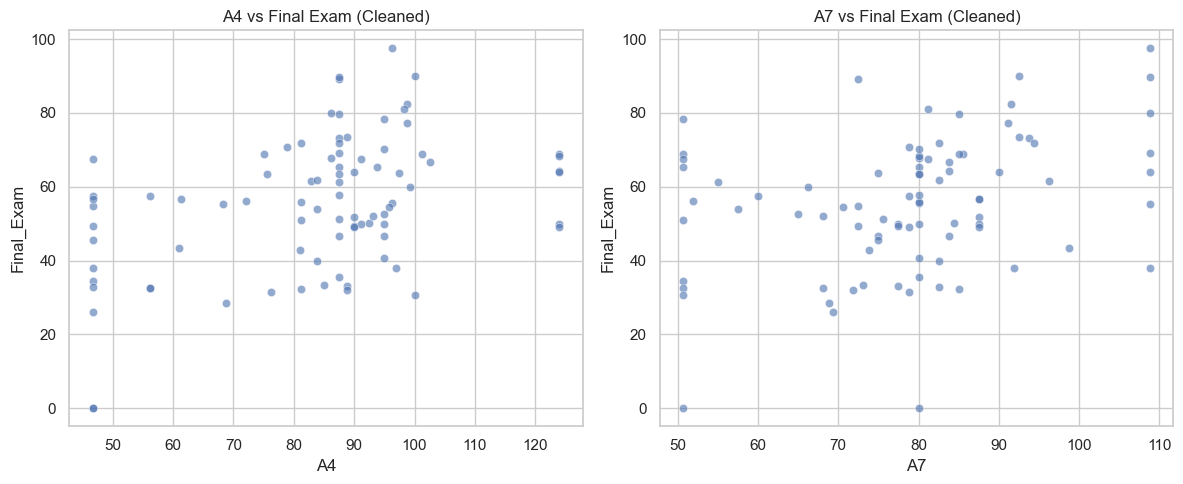

Units: All assignments kept in original points scale.
Missing values: Imputed using median (robust to outliers).
Outliers: Capped at IQR bounds (preserves N, reduces noise).
Top predictors: A4 and A7.


In [ ]:

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(data=df_final, x=top2[0], y='Final_Exam', alpha=0.6)
plt.title(f'{top2[0]} vs Final Exam (Cleaned)')

plt.subplot(1, 2, 2)
sns.scatterplot(data=df_final, x=top2[1], y='Final_Exam', alpha=0.6)
plt.title(f'{top2[1]} vs Final Exam (Cleaned)')

plt.tight_layout()
plt.show()

print("Units: All assignments kept in original points scale")
print("Missing values: Imputed using median (robust to outliers)")
print("Outliers: Capped at IQR bounds (preserves N, reduces noise)")
print(f"Top predictors: {top2[0]} and {top2[1]}.")

# References
Gemini was used to help create the comments and to help see if I actually did the assignment correctly.

https://gemini.google.com/share/263afa64b74c